# 07 Complexity Resource Analysis

Uses measured synthetic latency, CPU load, energy, and infrastructure-cost fields as practical resource proxies.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0,str(ROOT/"src"))
from dds_analysis import *
DATA=ROOT/"data"; OUT=ROOT/"outputs"; OUT.mkdir(exist_ok=True)
df=load_seqacs(DATA); validate_schema(df)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loaded 520,000 rows and 37 columns


In [2]:
cols=["latency_ms","pqc_cpu_load_pct","pqc_encryption_time_ms","energy_joules","infrastructure_cost_score"]
resource=df.groupby("scenario")[cols].mean()
resource.to_csv(OUT/"resource_complexity_proxies.csv"); display(resource)

,latency_ms,pqc_cpu_load_pct,pqc_encryption_time_ms,energy_joules,infrastructure_cost_score
scenario,,,,,
S1_Normal,31.983853,38.022046,3.554849,3.693626,0.739132
S2_Quantum_Eavesdropping,35.986734,41.026295,3.666413,3.813223,0.717274
S3_Harvest_Now_Decrypt_Later,34.022761,48.030508,3.916951,4.047185,0.726352
S4_QKD_Link_Failure,34.041397,42.076042,3.703892,3.192102,0.433391
S5_PQC_Computational_Overload,40.957541,81.836421,5.122206,5.320188,0.718043
S6_Hybrid_Adversarial_Attack,46.991674,64.952049,4.520871,4.749891,0.684929


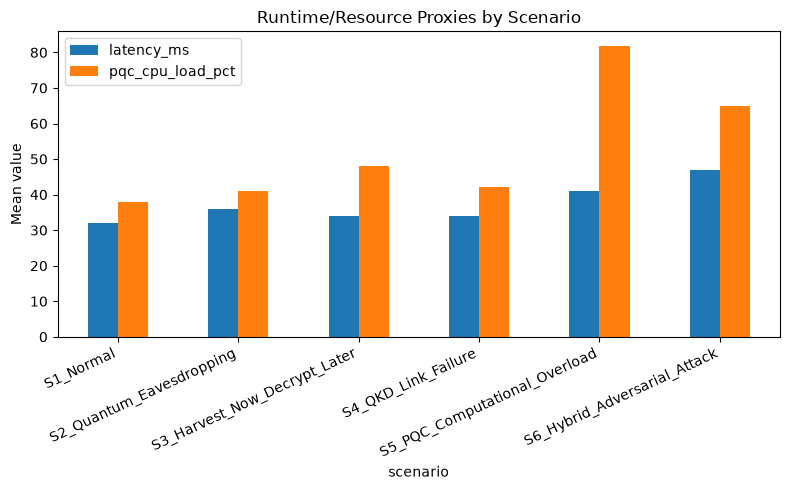

In [3]:
plt.figure(figsize=(8,5)); resource[["latency_ms","pqc_cpu_load_pct"]].plot(kind="bar",ax=plt.gca())
plt.ylabel("Mean value"); plt.title("Runtime/Resource Proxies by Scenario")
plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.savefig(OUT/"fig_resource_proxies.png",dpi=300); plt.show()